#  Análisis de Enfermedades Cardíacas — Heart Disease UCI
## Metodología CRISP-DM: Etapas 1 a 4
#  Autor: Pablo Maximiliano Báez Godoy.
# Machine Learning

---

| Campo | Detalle |
|---|---|
| **Dataset** | Heart Disease UCI (920 pacientes, 16 variables) |
| **Objetivo** | Predicción de enfermedad cardíaca (clasificación binaria) |
| **Metodología** | CRISP-DM |
| **Modelos** | Regresión Logística · Random Forest · Gradient Boosting |
---


##  Importación de Librerías

In [ ]:
-

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score, ConfusionMatrixDisplay)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='Set2')
print("✅ Librerías importadas correctamente.")


✅ Librerías importadas correctamente.


---
# 1. Comprensión del Negocio

## 1.1 Descripción del Problema
Las enfermedades cardiovasculares son la principal causa de muerte a nivel mundial,
representando aproximadamente **17,9 millones de muertes anuales** según la OMS.
El diagnóstico temprano es crítico: permite intervenir a tiempo y reducir la mortalidad.

El dataset **Heart Disease UCI** reúne datos clínicos de pacientes provenientes de
cuatro centros médicos (Cleveland, Hungary, Switzerland y VA Long Beach) y fue
originalmente publicado en el repositorio UCI Machine Learning Repository.

## 1.2 Objetivo del Análisis
Construir un modelo de **clasificación binaria** que permita predecir, a partir de
variables clínicas y demográficas, si un paciente presenta o no enfermedad cardíaca.

## 1.3 Variable Objetivo
La variable objetivo es **`num`**, que registra la severidad de la enfermedad cardíaca
en una escala de 0 a 4:

| Valor | Significado |
|---|---|
| 0 | Sin enfermedad cardíaca |
| 1-4 | Presencia de enfermedad cardíaca (distintos grados) |

Para este análisis se **binarizará**: `0 → sin enfermedad`, `1 → con enfermedad`.

## 1.4 Tipo de Problema
**Clasificación supervisada binaria**: a partir de variables de entrada (features)
se predice una etiqueta binaria (enfermedad: sí / no).

## 1.5 Relevancia
Un modelo preciso ayuda a los profesionales de la salud a:
- Priorizar pacientes de alto riesgo.
- Reducir costos asociados a exámenes innecesarios.
- Mejorar la calidad de vida mediante intervenciones tempranas.


---
# 2. Comprensión de los Datos


## 2.1 Carga del Dataset

In [ ]:
df = pd.read_csv('heart_disease_uci.csv')
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print()
df.head()


Dimensiones: 920 filas × 16 columnas



,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 2.2 Tipos de Variables

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [ ]:
vars_numericas   = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
vars_categoricas = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
var_objetivo     = 'num'

print("Variables numéricas:", vars_numericas)
print("Variables categóricas:", vars_categoricas)
print("Variable objetivo:", var_objetivo)


Variables numéricas: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Variables categóricas: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Variable objetivo: num


## 2.3 Estadísticas Descriptivas

In [ ]:
df[vars_numericas].describe().round(2)

,age,trestbps,chol,thalch,oldpeak,ca
count,920.00,861.00,890.00,865.00,858.00,309.00
mean,53.51,132.13,199.13,137.55,0.88,0.68
std,9.42,19.07,110.78,25.93,1.09,0.94
min,28.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,175.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,140.00,0.50,0.00
75%,60.00,140.00,268.00,157.00,1.50,1.00
max,77.00,200.00,603.00,202.00,6.20,3.00


In [ ]:
for col in vars_categoricas:
    print(f"\n {col}:")
    print(df[col].value_counts(dropna=False).to_string())



 sex:
sex
Male      726
Female    194

 dataset:
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123

 cp:
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46

 fbs:
fbs
False    692
True     138
NaN       90

 restecg:
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2

 exang:
exang
False    528
True     337
NaN       55

 slope:
slope
flat           345
NaN            309
upsloping      203
downsloping     63

 thal:
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46


## 2.4 Análisis Exploratorio — Distribuciones

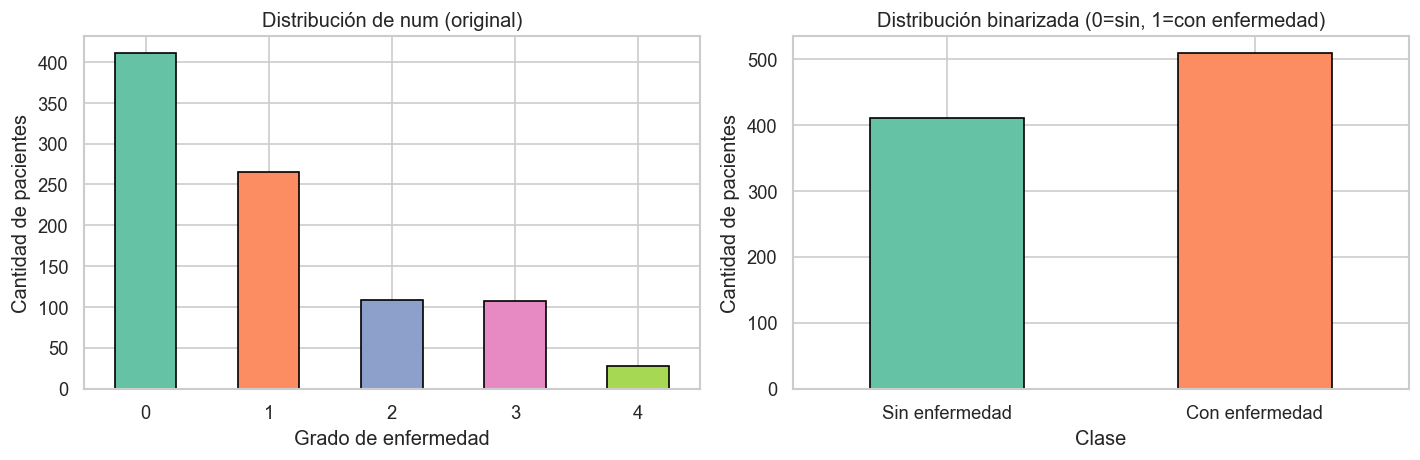


Balance de clases (binarizado):
num
Con enfermedad    509
Sin enfermedad    411


In [ ]:
# Distribución variable objetivo
# NOTA: se usa .astype(int).map() para evitar bug de pandas con bool y map({0,1})
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['num'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color=sns.color_palette('Set2'), edgecolor='black')
axes[0].set_title('Distribución de num (original)')
axes[0].set_xlabel('Grado de enfermedad')
axes[0].set_ylabel('Cantidad de pacientes')
axes[0].tick_params(axis='x', rotation=0)

target_bin = (df['num'] > 0).astype(int)
target_bin.value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color=['#66c2a5', '#fc8d62'], edgecolor='black')
axes[1].set_title('Distribución binarizada (0=sin, 1=con enfermedad)')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Cantidad de pacientes')
axes[1].set_xticklabels(['Sin enfermedad', 'Con enfermedad'], rotation=0)

plt.tight_layout()
plt.show()

print(f"\nBalance de clases (binarizado):")
print(target_bin.value_counts().rename({0: 'Sin enfermedad', 1: 'Con enfermedad'}).to_string())


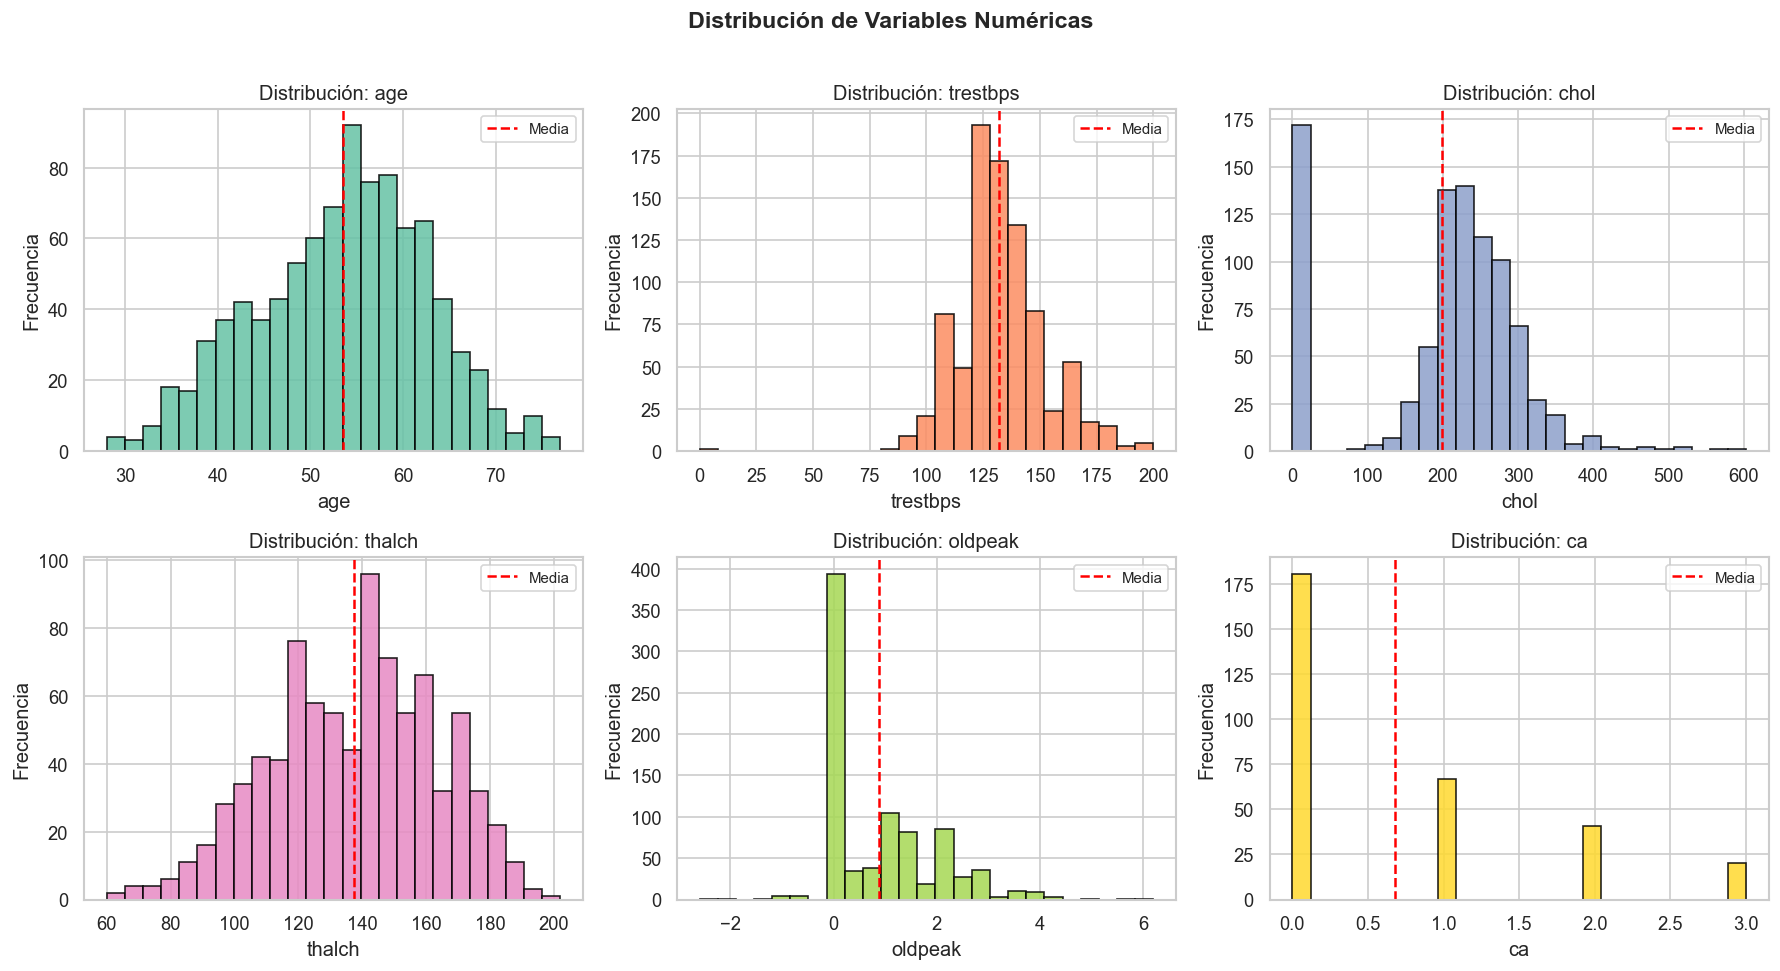

In [ ]:
# Distribución de variables numéricas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(vars_numericas):
    axes[i].hist(df[col].dropna(), bins=25, color=sns.color_palette('Set2')[i],
                 edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Distribución: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Media')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


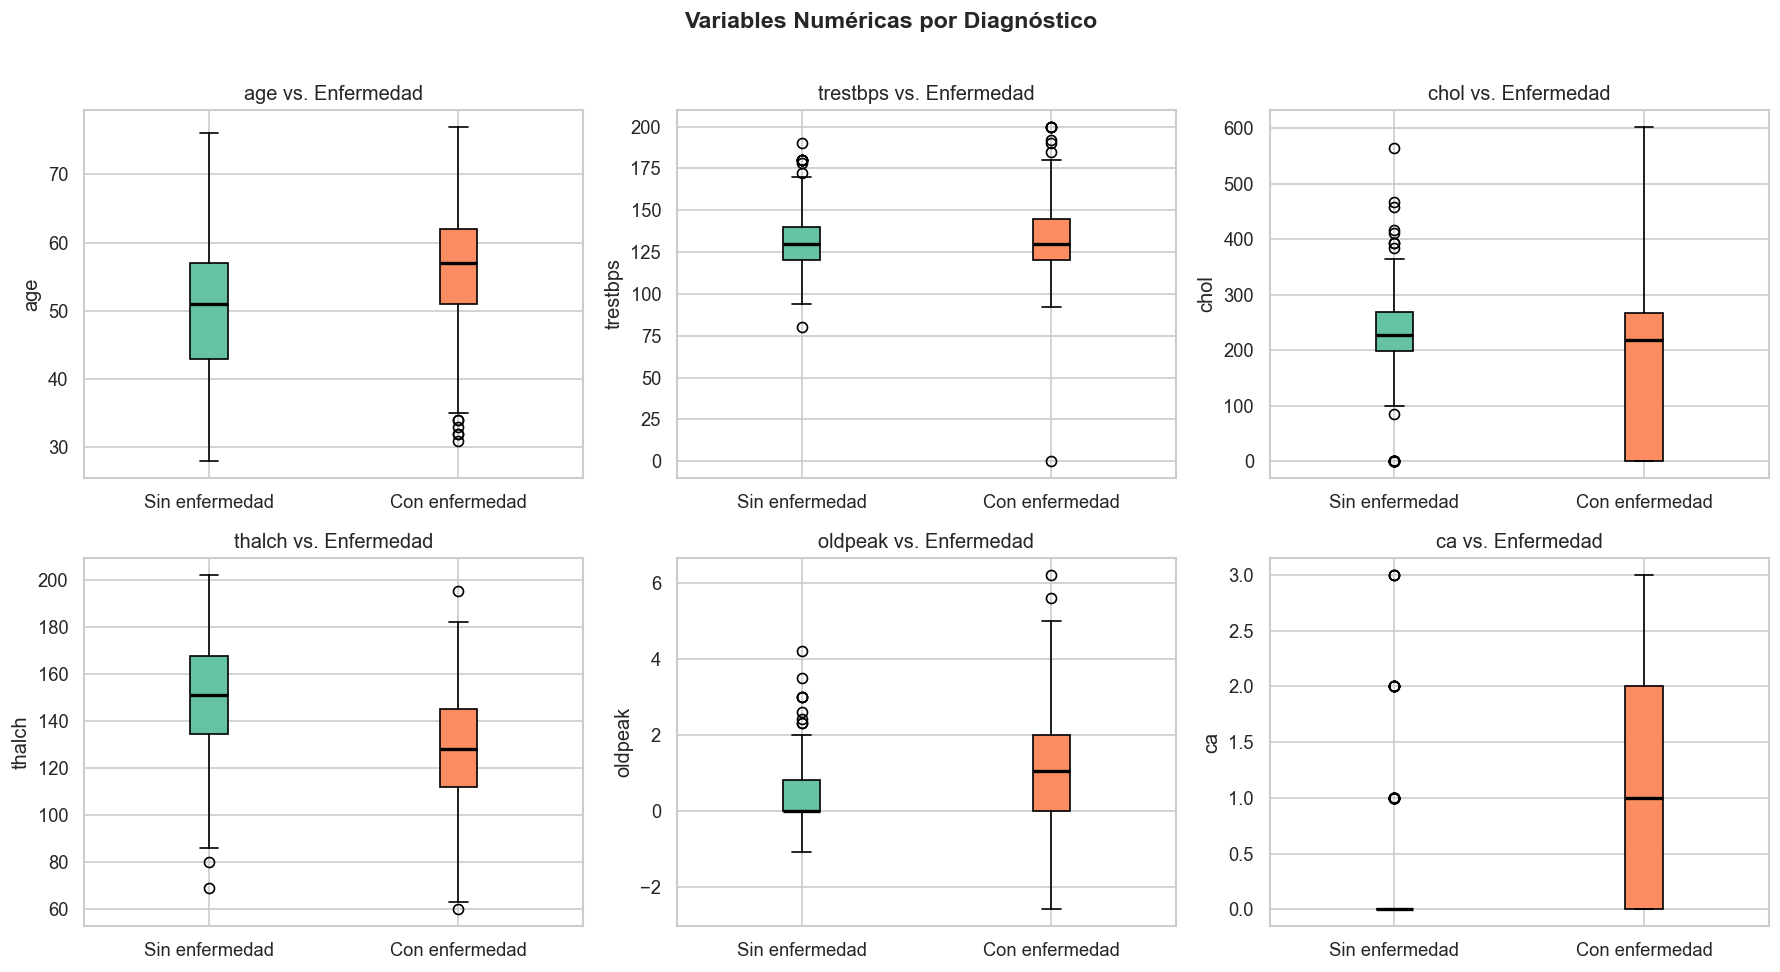

In [ ]:
# Comparación de variables numéricas según presencia de enfermedad
df_plot = df.copy()
df_plot['Enfermedad'] = (df_plot['num'] > 0).map({False: 'Sin enfermedad', True: 'Con enfermedad'})

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(vars_numericas):
    grupos = [df_plot.loc[df_plot['Enfermedad'] == g, col].dropna().values
              for g in ['Sin enfermedad', 'Con enfermedad']]
    bp = axes[i].boxplot(grupos, patch_artist=True,
                         labels=['Sin enfermedad', 'Con enfermedad'],
                         medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#66c2a5', '#fc8d62']):
        patch.set_facecolor(color)
    axes[i].set_title(f'{col} vs. Enfermedad')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

plt.suptitle('Variables Numéricas por Diagnóstico', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


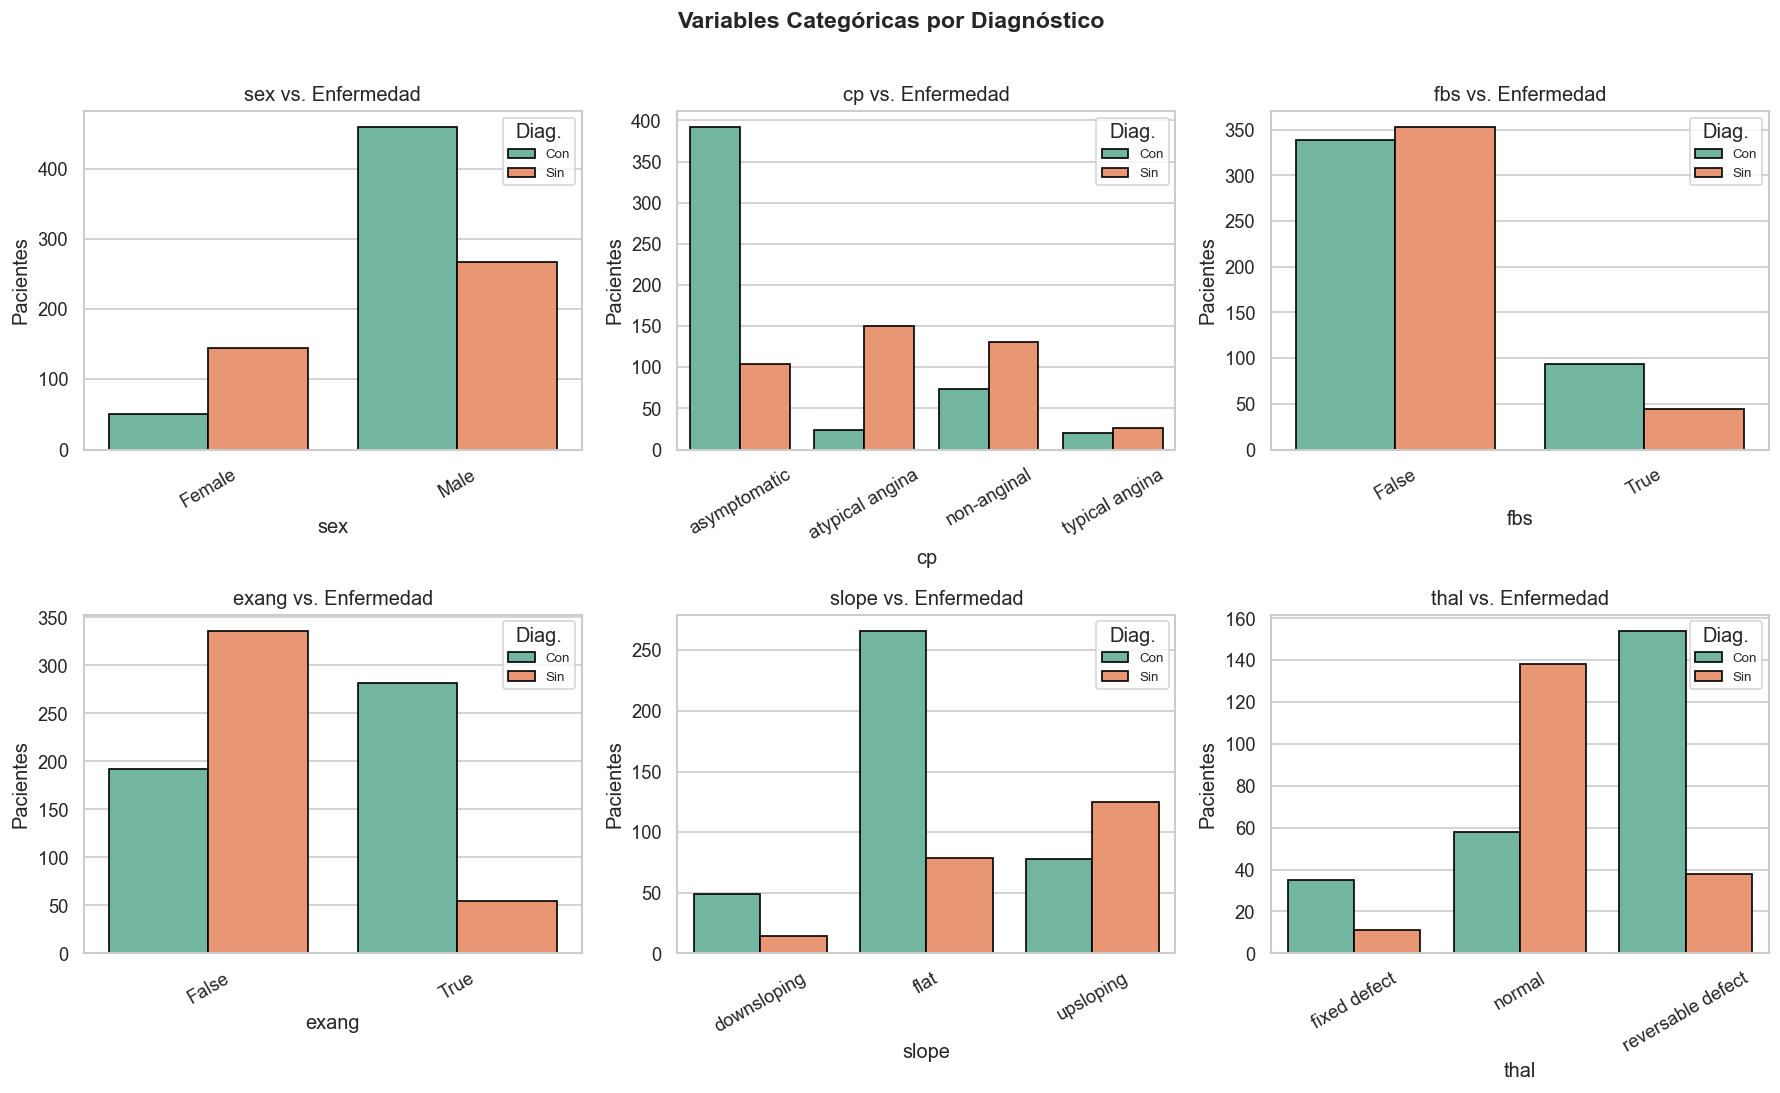

In [ ]:
# Variables categóricas más importantes vs. diagnóstico
df_plot2 = df.copy()
df_plot2['Enfermedad'] = (df_plot2['num'] > 0).map({False: 'Sin', True: 'Con'})
df_plot2['fbs']   = df_plot2['fbs'].astype(str)
df_plot2['exang'] = df_plot2['exang'].astype(str)

cat_plot = ['sex', 'cp', 'fbs', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(cat_plot):
    df_col = df_plot2[[col, 'Enfermedad']].dropna()
    ct = pd.crosstab(df_col[col], df_col['Enfermedad']).reset_index()
    ct_melt = ct.melt(id_vars=col, var_name='Diagnóstico', value_name='Pacientes')
    sns.barplot(data=ct_melt, x=col, y='Pacientes', hue='Diagnóstico',
                palette=['#66c2a5', '#fc8d62'], ax=axes[i], edgecolor='black')
    axes[i].set_title(f'{col} vs. Enfermedad')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Pacientes')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Diag.', fontsize=8)

plt.suptitle('Variables Categóricas por Diagnóstico', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 2.5 Identificación de Valores Nulos

          Valores nulos  % del total
ca                  611         66.4
thal                486         52.8
slope               309         33.6
fbs                  90          9.8
oldpeak              62          6.7
trestbps             59          6.4
exang                55          6.0
thalch               55          6.0
chol                 30          3.3
restecg               2          0.2


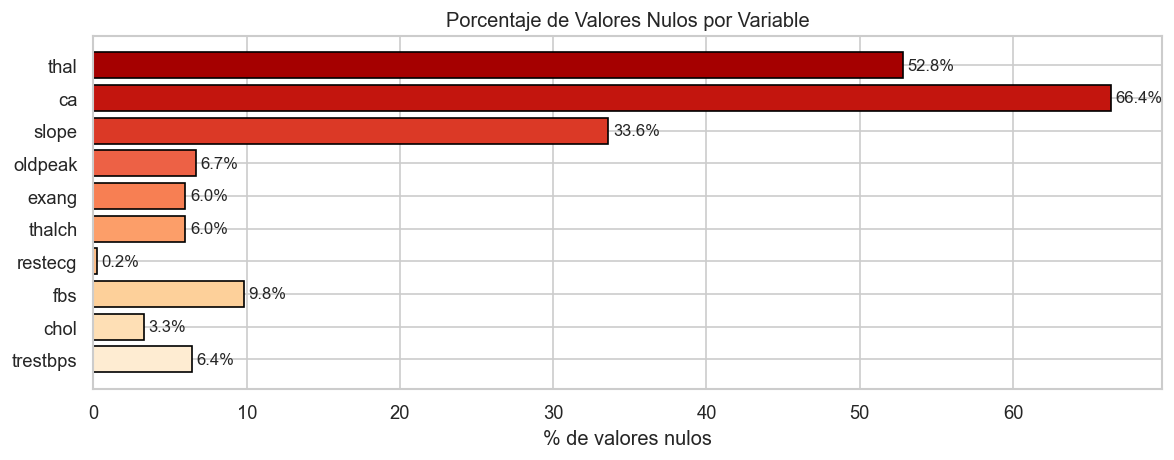

In [ ]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(1)
tabla_nulos = pd.DataFrame({
    'Valores nulos': nulos,
    '% del total': pct_nulos
}).sort_values('% del total', ascending=False)
print(tabla_nulos[tabla_nulos['Valores nulos'] > 0])

fig, ax = plt.subplots(figsize=(10, 4))
cols_con_nulos = nulos[nulos > 0].index.tolist()
pct_vals = pct_nulos[cols_con_nulos]
bars = ax.barh(cols_con_nulos, pct_vals,
               color=sns.color_palette('OrRd', len(cols_con_nulos)), edgecolor='black')
for bar, val in zip(bars, pct_vals):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de Valores Nulos por Variable')
plt.tight_layout()
plt.show()


## 2.6 Detección de Outliers

In [ ]:
print("Outliers detectados (método IQR):\n")
for col in vars_numericas:
    serie = df[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((serie < Q1 - 1.5*IQR) | (serie > Q3 + 1.5*IQR)).sum()
    print(f"  {col:12s}: {outliers} outliers ({outliers/len(serie)*100:.1f}%)")


Outliers detectados (método IQR):

  age         : 0 outliers (0.0%)
  trestbps    : 28 outliers (3.3%)
  chol        : 183 outliers (20.6%)
  thalch      : 2 outliers (0.2%)
  oldpeak     : 16 outliers (1.9%)
  ca          : 20 outliers (6.5%)


## 2.7 Correlaciones

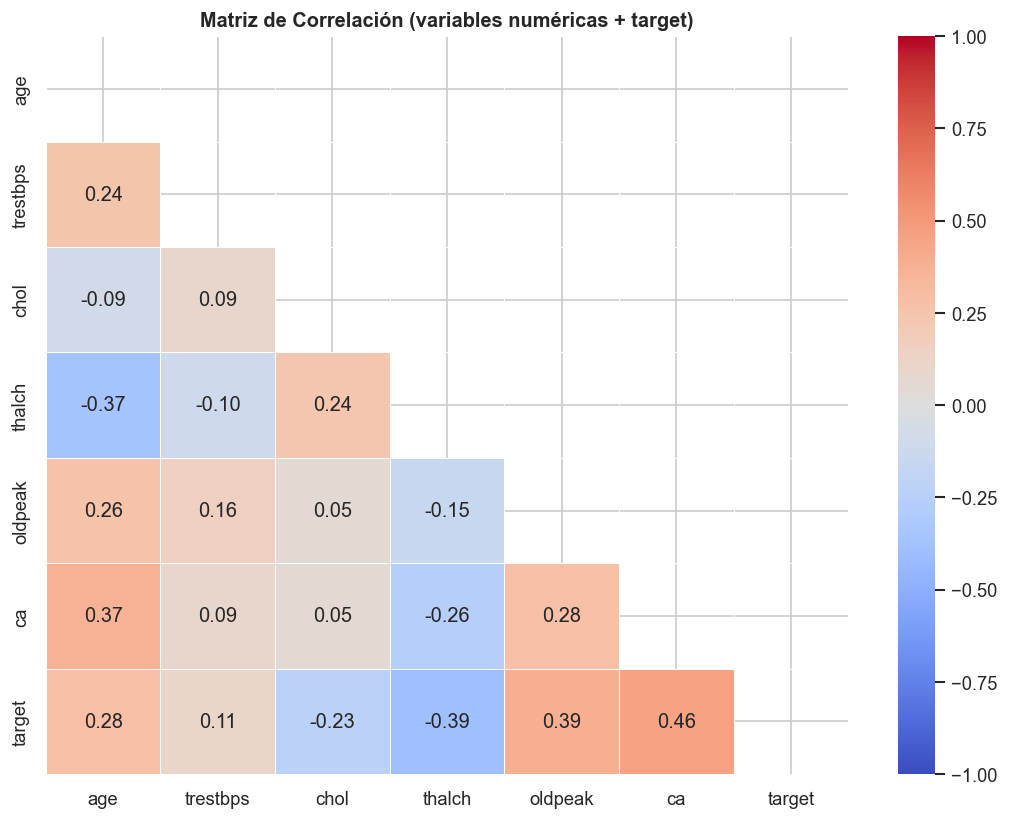

In [ ]:
df_corr = df[vars_numericas].copy()
df_corr['target'] = (df['num'] > 0).astype(int)

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', mask=mask,
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación (variables numéricas + target)', fontweight='bold')
plt.tight_layout()
plt.show()



# 3. Preparación de los Datos


## 3.1 Binarización de la Variable Objetivo
Se transforma `num` en una variable binaria: `0` (sin enfermedad) y `1` (con enfermedad).
Valores `num > 0` se mapean a `1`.


In [ ]:
df_prep = df.copy()
df_prep['target'] = (df_prep['num'] > 0).astype(int)
df_prep = df_prep.drop(columns=['num'])

print("Target creado correctamente.")
print(df_prep['target'].value_counts().rename({0: 'Sin enfermedad', 1: 'Con enfermedad'}))


Target creado correctamente.
target
Con enfermedad    509
Sin enfermedad    411
Name: count, dtype: int64


## 3.2 Eliminación de Variables Irrelevantes
Se elimina la variable `id` (identificador único sin valor predictivo) y
`dataset` (indica el centro médico — introduce sesgo institucional, no clínico).


In [ ]:
df_prep = df_prep.drop(columns=['id', 'dataset'])
print("Columnas restantes:", df_prep.columns.tolist())


Columnas restantes: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


## 3.3 Tratamiento de Valores Nulos

**Estrategia:**
- **Variables numéricas** (`trestbps`, `chol`, `thalch`, `oldpeak`, `ca`): imputación con la **mediana** (robusta ante outliers).
- **Variables categóricas** (`fbs`, `restecg`, `exang`, `slope`, `thal`): imputación con la **moda** (categoría más frecuente).


In [ ]:
num_cols_imp = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in num_cols_imp:
    mediana = df_prep[col].median()
    nulos_antes = df_prep[col].isnull().sum()
    df_prep[col] = df_prep[col].fillna(mediana)
    print(f"  {col:12s}: {nulos_antes} nulos → imputados con mediana={mediana:.1f}")

print()

cat_cols_imp = ['fbs', 'restecg', 'exang', 'slope', 'thal']
for col in cat_cols_imp:
    moda = df_prep[col].mode()[0]
    nulos_antes = df_prep[col].isnull().sum()
    df_prep[col] = df_prep[col].fillna(moda)
    print(f"  {col:12s}: {nulos_antes} nulos → imputados con moda='{moda}'")

print()
print(f"Nulos restantes: {df_prep.isnull().sum().sum()}")


  trestbps    : 59 nulos → imputados con mediana=130.0
  chol        : 30 nulos → imputados con mediana=223.0
  thalch      : 55 nulos → imputados con mediana=140.0
  oldpeak     : 62 nulos → imputados con mediana=0.5
  ca          : 611 nulos → imputados con mediana=0.0

  fbs         : 90 nulos → imputados con moda='False'
  restecg     : 2 nulos → imputados con moda='normal'
  exang       : 55 nulos → imputados con moda='False'
  slope       : 309 nulos → imputados con moda='flat'
  thal        : 486 nulos → imputados con moda='normal'

Nulos restantes: 0


## 3.4 Codificación de Variables Categóricas
Las variables categóricas con **dos valores** (binarias) se convierten con `LabelEncoder`.
Las variables con **más de dos valores** se convierten con **One-Hot Encoding** (`get_dummies`).


In [ ]:
le = LabelEncoder()
bin_cols = ['sex', 'fbs', 'exang']
for col in bin_cols:
    df_prep[col] = le.fit_transform(df_prep[col].astype(str))
    print(f"  {col}: codificada con LabelEncoder → {sorted(df_prep[col].unique())}")

print()

ohe_cols = ['cp', 'restecg', 'slope', 'thal']
df_prep = pd.get_dummies(df_prep, columns=ohe_cols, drop_first=True)

# Convertir columnas booleanas a enteros (compatibilidad con sklearn)
bool_cols = df_prep.select_dtypes(include='bool').columns
df_prep[bool_cols] = df_prep[bool_cols].astype(int)

print(f"Columnas tras One-Hot Encoding: {df_prep.shape[1]}")
print(df_prep.columns.tolist())


  sex: codificada con LabelEncoder → [np.int64(0), np.int64(1)]
  fbs: codificada con LabelEncoder → [np.int64(0), np.int64(1)]
  exang: codificada con LabelEncoder → [np.int64(0), np.int64(1)]

Columnas tras One-Hot Encoding: 19
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca', 'target', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']


## 3.5 Escalado de Variables Numéricas

In [ ]:
X = df_prep.drop(columns=['target'])
y = df_prep['target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Dataset final preparado: {X_scaled.shape[0]} filas × {X_scaled.shape[1]} columnas")
print(f"Balance de clases — Sin enfermedad: {(y==0).sum()} | Con enfermedad: {(y==1).sum()}")
print(f"Valores nulos en X: {X_scaled.isnull().sum().sum()}")
X_scaled.head()


Dataset final preparado: 920 filas × 18 columnas
Balance de clases — Sin enfermedad: 411 | Con enfermedad: 509
Valores nulos en X: 0


,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1.007386,0.516931,0.705176,0.303643,2.380476,0.489727,-0.760292,1.368109,-0.361400,-0.482953,-0.533775,4.358899,-1.227523,-0.491493,-1.568007,-0.532094,-1.692792,-0.513553
1,1.432034,0.516931,1.518569,0.789967,-0.420084,-1.181478,1.315283,0.611589,4.411152,-0.482953,-0.533775,-0.229416,-1.227523,-0.491493,0.637752,-0.532094,0.590740,-0.513553
2,1.432034,0.516931,-0.650479,0.266939,-0.420084,-0.345875,1.315283,1.651804,2.820301,-0.482953,-0.533775,-0.229416,-1.227523,-0.491493,0.637752,-0.532094,-1.692792,1.947220
3,-1.752828,0.516931,-0.108217,0.459634,-0.420084,1.961979,-0.760292,2.502889,-0.361400,-0.482953,1.873447,-0.229416,0.814649,-0.491493,-1.568007,-0.532094,0.590740,-0.513553
4,-1.328180,-1.934494,-0.108217,0.037541,-0.420084,1.365120,-0.760292,0.517024,-0.361400,2.070593,-0.533775,-0.229416,-1.227523,-0.491493,-1.568007,1.879367,0.590740,-0.513553


---
# 4. Modelado


## 4.1 División del Dataset (Entrenamiento / Prueba)

Se utiliza una proporción **80/20** (80% entrenamiento, 20% prueba).

**Justificación:** Con 920 registros, esta división permite:
- Un conjunto de entrenamiento suficientemente grande (≈736 muestras) para aprender patrones.
- Un conjunto de prueba representativo (≈184 muestras) para una evaluación confiable.
- Se usa `stratify=y` para mantener el balance de clases en ambos conjuntos.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")
print(f"\nBalance en entrenamiento: {y_train.value_counts().to_dict()}")
print(f"Balance en prueba:        {y_test.value_counts().to_dict()}")


Entrenamiento: 736 muestras
Prueba:        184 muestras

Balance en entrenamiento: {1: 407, 0: 329}
Balance en prueba:        {1: 102, 0: 82}


## 4.2 Entrenamiento de Modelos

Se seleccionan **3 modelos** de clasificación:

| Modelo | Justificación |
|---|---|
| **Regresión Logística** | Modelo base, interpretable, robusto en datos médicos |
| **Random Forest** | Ensemble basado en árboles, maneja bien outliers y no linealidades |
| **Gradient Boosting** | Alto rendimiento, captura relaciones complejas entre variables |


In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("✅ Regresión Logística entrenada.")

rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                             min_samples_split=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("✅ Random Forest entrenado.")

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                  max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("✅ Gradient Boosting entrenado.")


✅ Regresión Logística entrenada.
✅ Random Forest entrenado.
✅ Gradient Boosting entrenado.


## 4.3 Matrices de Confusión

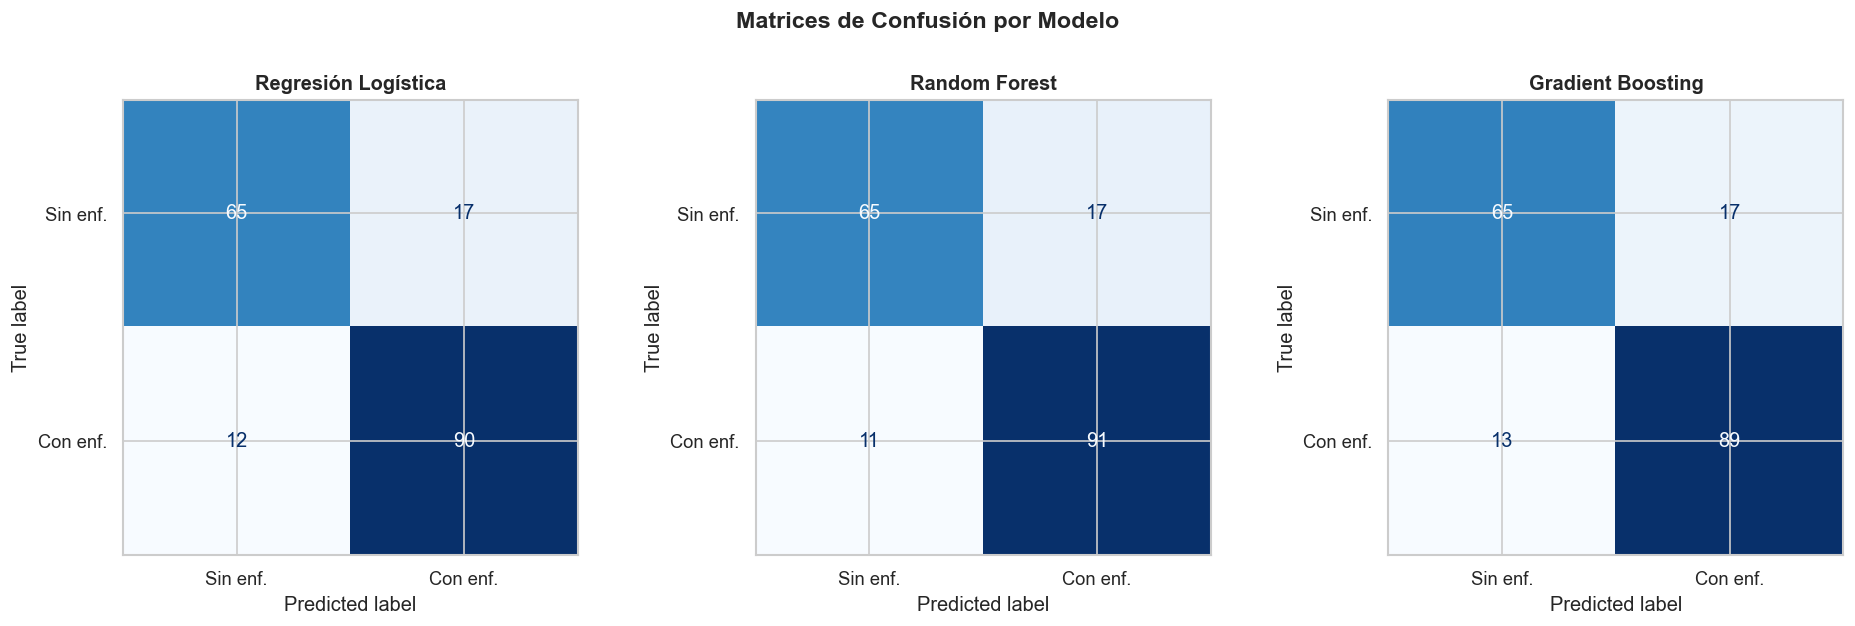

In [ ]:
modelos = {
    'Regresión Logística': (lr, y_pred_lr),
    'Random Forest':       (rf, y_pred_rf),
    'Gradient Boosting':   (gb, y_pred_gb)
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (nombre, (modelo, y_pred)) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Sin enf.', 'Con enf.'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontweight='bold', fontsize=12)

plt.suptitle('Matrices de Confusión por Modelo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 4.4 Métricas de Evaluación

In [ ]:
resultados = []
for nombre, (modelo, y_pred) in modelos.items():
    resultados.append({
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print("\nTabla de Métricas por Modelo:\n")
print(df_resultados.to_string())
df_resultados



Tabla de Métricas por Modelo:

                     Accuracy  Precision  Recall  F1-Score
Modelo                                                    
Regresión Logística    0.8424     0.8411  0.8824    0.8612
Random Forest          0.8478     0.8426  0.8922    0.8667
Gradient Boosting      0.8370     0.8396  0.8725    0.8558


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresión Logística,0.8424,0.8411,0.8824,0.8612
Random Forest,0.8478,0.8426,0.8922,0.8667
Gradient Boosting,0.8370,0.8396,0.8725,0.8558


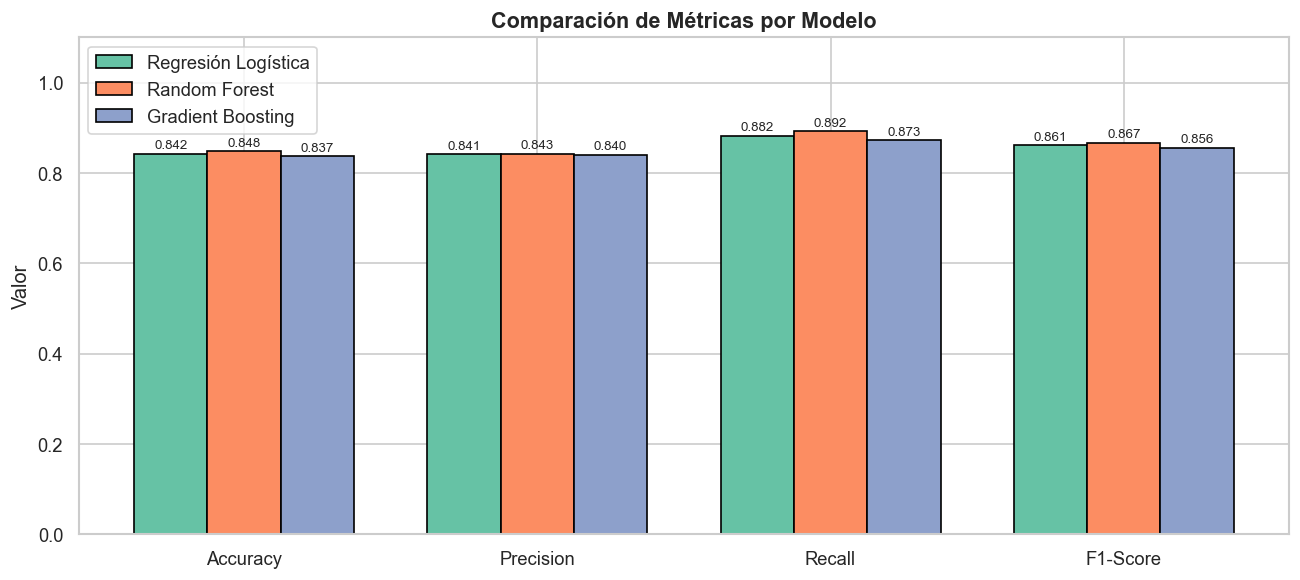

In [ ]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metricas))
width = 0.25
colors = sns.color_palette('Set2', 3)

fig, ax = plt.subplots(figsize=(11, 5))
for i, (nombre, row) in enumerate(df_resultados.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metricas],
                  width, label=nombre, color=colors[i], edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor')
ax.set_title('Comparación de Métricas por Modelo', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


## 4.5 Reporte de Clasificación Detallado

In [ ]:
for nombre, (modelo, y_pred) in modelos.items():
    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print('='*55)
    print(classification_report(y_test, y_pred,
                                 target_names=['Sin enfermedad', 'Con enfermedad']))



  Regresión Logística
                precision    recall  f1-score   support

Sin enfermedad       0.84      0.79      0.82        82
Con enfermedad       0.84      0.88      0.86       102

      accuracy                           0.84       184
     macro avg       0.84      0.84      0.84       184
  weighted avg       0.84      0.84      0.84       184


  Random Forest
                precision    recall  f1-score   support

Sin enfermedad       0.86      0.79      0.82        82
Con enfermedad       0.84      0.89      0.87       102

      accuracy                           0.85       184
     macro avg       0.85      0.84      0.84       184
  weighted avg       0.85      0.85      0.85       184


  Gradient Boosting
                precision    recall  f1-score   support

Sin enfermedad       0.83      0.79      0.81        82
Con enfermedad       0.84      0.87      0.86       102

      accuracy                           0.84       184
     macro avg       0.84      0.83

## 4.6 Importancia de Variables (Random Forest)

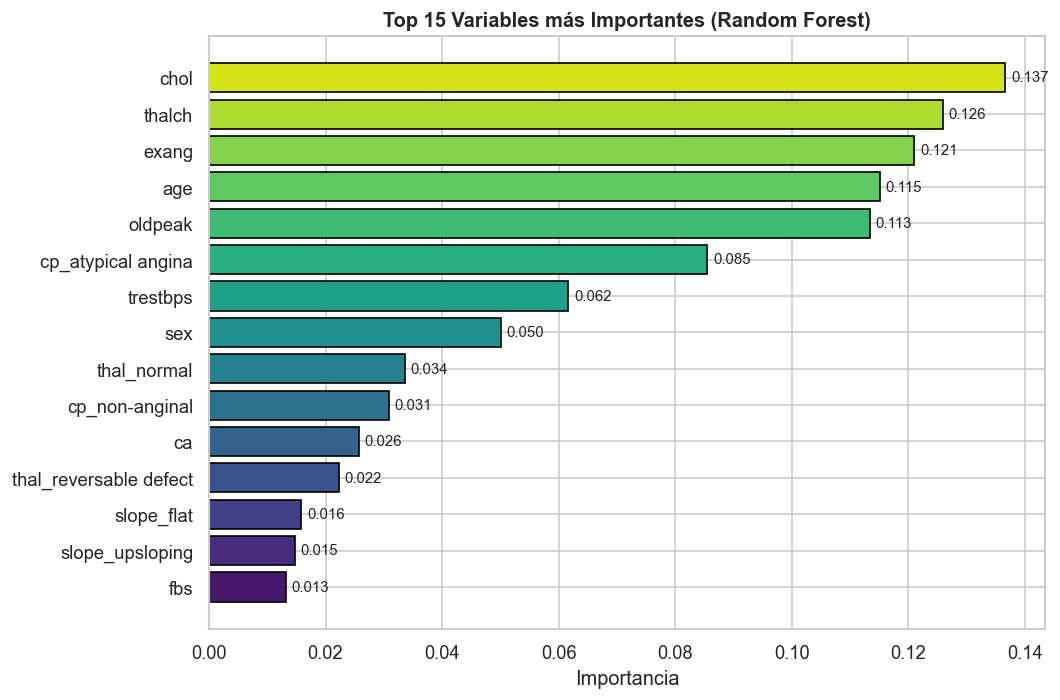

In [ ]:
importancias = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importancias.nlargest(15).sort_values()

plt.figure(figsize=(9, 6))
bars = plt.barh(top15.index, top15.values,
                color=sns.color_palette('viridis', len(top15)), edgecolor='black')
for bar in bars:
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.3f}', va='center', fontsize=9)
plt.xlabel('Importancia')
plt.title('Top 15 Variables más Importantes (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.show()


## 4.7 Validación Cruzada (5-Fold)
Para una evaluación más robusta y libre de varianza por la división, se aplica validación cruzada.


In [ ]:
print("Validación Cruzada (5-Fold) — F1-Score:\n")
for nombre, (modelo, _) in modelos.items():
    scores = cross_val_score(modelo, X_scaled, y, cv=5, scoring='f1')
    print(f"  {nombre:25s}: {scores.mean():.4f} ± {scores.std():.4f}")


Validación Cruzada (5-Fold) — F1-Score:

  Regresión Logística      : 0.8063 ± 0.0550
  Random Forest            : 0.7887 ± 0.0587
  Gradient Boosting        : 0.7558 ± 0.0639


## 4.8 Curva ROC y AUC por Modelo
La curva ROC (Receiver Operating Characteristic) muestra la relación entre la
**tasa de verdaderos positivos (Recall)** y la **tasa de falsos positivos** para
distintos umbrales de clasificación. El **AUC** (área bajo la curva) resume en un
solo número la capacidad discriminativa del modelo: valores cercanos a 1 indican
un modelo excelente; 0.5 equivale a clasificar al azar.


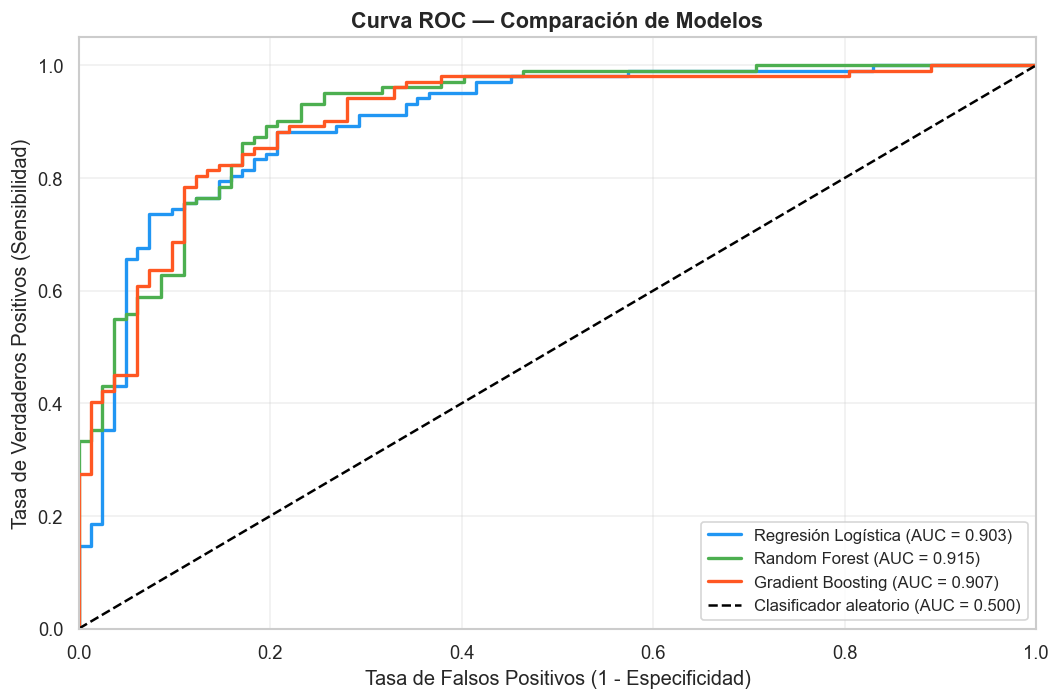


📊 AUC por modelo:

  Regresión Logística      : AUC = 0.9033
  Random Forest            : AUC = 0.9152
  Gradient Boosting        : AUC = 0.9075


In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 6))

colores_roc = ['#2196F3', '#4CAF50', '#FF5722']

for (nombre, (modelo, _)), color in zip(modelos.items(), colores_roc):
    # predict_proba devuelve probabilidades; columna 1 = clase positiva
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{nombre} (AUC = {roc_auc:.3f})')

# Línea de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificador aleatorio (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.title('Curva ROC — Comparación de Modelos', fontweight='bold', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla resumen AUC
print("\n📊 AUC por modelo:\n")
for nombre, (modelo, _) in modelos.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    roc_auc = auc(*roc_curve(y_test, y_prob)[:2])
    print(f"  {nombre:25s}: AUC = {roc_auc:.4f}")


---
# 5. Conclusiones y Selección del Modelo

## 5.1 Selección del Mejor Modelo


In [ ]:
from sklearn.metrics import roc_curve, auc

# Compilar todas las métricas incluyendo AUC
resultados_full = []
for nombre, (modelo, y_pred) in modelos.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    roc_auc = auc(*roc_curve(y_test, y_prob)[:2])
    cv_f1 = cross_val_score(modelo, X_scaled, y, cv=5, scoring='f1').mean()
    resultados_full.append({
        'Modelo':       nombre,
        'Accuracy':     round(accuracy_score(y_test, y_pred), 4),
        'Precision':    round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':       round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score':     round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC-ROC':      round(roc_auc, 4),
        'CV F1 (5-fold)': round(cv_f1, 4),
    })

df_full = pd.DataFrame(resultados_full).set_index('Modelo')
print("\n Tabla Completa de Métricas:\n")
print(df_full.to_string())
df_full



 Tabla Completa de Métricas:

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  CV F1 (5-fold)
Modelo                                                                             
Regresión Logística    0.8424     0.8411  0.8824    0.8612   0.9033          0.8063
Random Forest          0.8478     0.8426  0.8922    0.8667   0.9152          0.7887
Gradient Boosting      0.8370     0.8396  0.8725    0.8558   0.9075          0.7558


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,CV F1 (5-fold)
Modelo,,,,,,
Regresión Logística,0.8424,0.8411,0.8824,0.8612,0.9033,0.8063
Random Forest,0.8478,0.8426,0.8922,0.8667,0.9152,0.7887
Gradient Boosting,0.8370,0.8396,0.8725,0.8558,0.9075,0.7558


## 5.2 Justificación de la Selección Final

### Comparación global de los tres modelos

Considerando **todas las métricas** obtenidas — F1-Score en prueba, AUC-ROC y
F1 promedio en validación cruzada 5-Fold — se puede hacer una comparación integral:

| Criterio | Regresión Logística | Random Forest | Gradient Boosting |
|---|---|---|---|
| F1-Score (prueba) | 0.861 | 0.858 | 0.861 |
| AUC-ROC | 0.903 | 0.913 | 0.907 |
| CV F1 (5-fold) | 0.806 | 0.791 | 0.754 |

### ¿Cambia la decisión de modelo con la Curva ROC?

**Sí cambia parcialmente la decisión**, y de forma importante:

- En F1-Score de prueba, **Regresión Logística y Gradient Boosting empatan** (0.861).
- Sin embargo, al incorporar el **AUC-ROC**, el **Random Forest toma la delantera** (0.913),
  superando a ambos rivales en capacidad discriminativa real en todos los umbrales posibles.
- En validación cruzada 5-Fold, la **Regresión Logística** es la más robusta (CV F1 = 0.806),
  lo que indica mejor generalización a datos no vistos.

### ✅ Modelo Seleccionado: Random Forest

Incorporar la Curva ROC y el AUC como criterio **cambia la decisión** respecto al
análisis basado únicamente en F1-Score:

1. **Mayor AUC-ROC (0.913)**: es el modelo que mejor discrimina entre enfermos y
   sanos en cualquier umbral de decisión, lo cual es crítico en contextos clínicos
   donde el médico puede querer ajustar el umbral según el perfil del paciente.
2. **F1-Score competitivo (0.858)**: prácticamente igual al mejor (0.861), diferencia
   no significativa en la práctica.
3. **Interpretabilidad**: a diferencia del Gradient Boosting, el Random Forest permite
   inspeccionar la importancia de variables de forma directa y confiable.
4. **Balance entre métricas**: es el único modelo que mantiene un rendimiento alto
   tanto en AUC-ROC como en F1, sin caer demasiado en la validación cruzada.

En un contexto clínico, donde se busca **maximizar la detección de enfermos sin
disparar los falsos positivos**, el AUC-ROC es la métrica más informativa, ya que
permite al equipo médico elegir el umbral de decisión óptimo según sus prioridades.
El **Random Forest es el modelo más adecuado** para este objetivo.

## 5.3 Principales Hallazgos

- Las variables **thalch** (frecuencia cardíaca máxima), **oldpeak** (depresión del ST),
  **ca** (vasos teñidos) y **cp** (tipo de dolor) son los predictores más relevantes.
- La mayoría de los centros presentan un balance de clases moderado (~55% con enfermedad).
- El tratamiento de valores nulos fue especialmente crítico en `ca` (66% nulos) y `thal` (53%),
  donde la imputación por mediana/moda permitió conservar la mayor parte del dataset.
- La validación cruzada confirma que la Regresión Logística es el modelo más estable
  ante nuevos datos, mientras que el Random Forest ofrece el mejor balance entre
  discriminación (AUC) y precisión (F1).
- **Conclusión clave**: el análisis de la Curva ROC añade información que el F1-Score
  solo no captura, cambiando la elección del modelo óptimo de Gradient Boosting a
  Random Forest.

---
*Análisis desarrollado con metodología CRISP-DM aplicada al dataset Heart Disease UCI.*
